<a href="https://colab.research.google.com/github/JuanMelendres/proyecto_integrador_equipo19/blob/master/Avance5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Avance 5. Modelo final

---



---



##Optimización de flujos quirúrgicos mediante IA

###Oscar Damián Vela Noyola A00821831
###Juan Antonio Melendres Villa A00369017
###Miguel Ángel Villanueva Amador A01793890


#### Librerías

Importamos las librerias que se llegaran a necesitar

In [ ]:
# --- Importaciones esenciales para análisis de datos y visualización ---
import pandas as pd  # Manipulación y análisis eficiente de datos tabulares
import matplotlib.pyplot as plt  # Creación de gráficos personalizados
import seaborn as sns  # Visualización estadística avanzada basada en matplotlib
import numpy as np  # Operaciones matemáticas avanzadas y manejo eficiente de arrays
from IPython.display import display, HTML  # Mostrar tablas y HTML en Jupyter notebooks

# --- Estadística y análisis avanzado ---
from scipy import stats  # Funciones estadísticas avanzadas como pruebas de hipótesis y distribuciones

# --- Clustering y modelado de texto ---
from sklearn.cluster import KMeans  # Clustering no supervisado para agrupamiento de datos
from gensim import corpora  # Creación de corpus para análisis de texto en modelos temáticos
from gensim.models import LsiModel  # Modelado de temas mediante Latent Semantic Indexing (LSI)
from gensim.models import CoherenceModel  # Evaluación de coherencia para modelos de temas
from sklearn.preprocessing import StandardScaler  # Estandarización de datos, útil para algoritmos que requieren datos escalados

# --- Transformación y normalización de datos ---
from sklearn.preprocessing import MinMaxScaler  # Normalización de datos en un rango específico (0,1)
from imblearn.over_sampling import SMOTE  # Aumento de muestras para datos desbalanceados mediante SMOTE

# --- Modelos de clasificación y evaluación ---
from sklearn.svm import SVC  # Máquina de soporte vectorial (SVM) para clasificación
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Clasificación con árboles de decisión
from sklearn.naive_bayes import GaussianNB  # Clasificación usando Naive Bayes
from sklearn.neighbors import KNeighborsClassifier  # Clasificación con K-vecinos más cercanos (KNN)
from sklearn.neural_network import MLPClassifier  # Clasificación con redes neuronales (MLP)
from sklearn.linear_model import LogisticRegression  # Regresión Logística para clasificación binaria o multiclase

# --- Ensamblado y métodos avanzados de clasificación ---
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier  # Algoritmos de ensamblado
from sklearn.feature_selection import RFE  # Selección de características mediante eliminación recursiva

# --- Herramientas para modelado y validación ---
from sklearn.model_selection import GridSearchCV  # Búsqueda de hiperparámetros mediante validación cruzada
from sklearn.model_selection import cross_val_score, train_test_split, learning_curve  # Validación cruzada, división de datos y curvas de aprendizaje

# --- Métricas de evaluación ---
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score  # Métricas de evaluación
from sklearn.metrics import precision_recall_curve, average_precision_score  # Curvas de precisión y métricas de evaluación avanzadas
from sklearn.preprocessing import label_binarize  # Binarización de etiquetas para ROC multiclasificación

# --- Control de tiempo ---
import time  # Control del tiempo de ejecución

# --- Gestión de advertencias ---
import warnings  # Control de advertencias
warnings.filterwarnings('ignore')  # Supresión de advertencias para evitar ruido en la salida

#### Cargar set de datos original

Cargamos el data set original

In [ ]:
# Load the data from the first sheet, and assign it to variable "df"
df = pd.read_excel('variables_quirurgicas_finales.xlsx')
# Show the first 10 rows using dataframe.head() method
df.head(10)

,edad_n,peso_yj_n,tallacm_n,imc_yj_n,hto_yj_n,leucostotales_yj_n,neutrofilos_yj_n,tp_yj_n,ttp_yj_n,glucosa_yj_n,...,qsanormal,sexo_binary,anestesia_2,anestesia_3,anestesia_4,anestesia_5,nitritos_binary,egoinfeccin_binary,egoanormal_binary,riesgo_quirurgico
0,-0.302744,0.135252,0.293533,0.266600,-0.031104,0.309829,0.013707,0.385542,0.208330,0.573646,...,0,1,1,0,0,0,0,0,1,1
1,-0.969248,0.022076,-0.057890,0.266600,-0.071345,0.614379,0.637991,0.176659,0.174646,0.521957,...,1,0,0,0,0,0,0,0,0,2
2,0.190040,-0.009149,-0.057890,0.237438,-0.319087,0.020478,0.051430,0.163757,-0.087805,0.569326,...,1,0,0,0,0,0,0,0,0,3
3,-0.380527,0.148237,-0.163066,0.413111,-0.251789,0.171215,0.026994,0.237176,0.067576,0.494980,...,0,0,0,0,0,0,0,0,0,2
4,-0.075975,0.173521,-0.022805,0.394822,0.108825,0.160273,-0.262229,0.176659,0.081984,0.551329,...,0,1,0,0,0,0,0,0,0,2
5,-0.733886,0.094835,-0.057890,0.333700,-0.378056,0.769683,0.871388,0.441306,0.040554,0.644456,...,1,1,0,0,0,0,0,0,0,2
6,0.537220,0.135252,0.293533,0.266600,-0.509317,0.413679,0.159186,0.426109,-0.046407,0.598190,...,1,1,0,0,0,0,0,0,0,2
7,0.446171,0.155917,-0.512783,0.522450,-0.231825,-0.025226,-0.373878,0.340914,0.109591,0.551329,...,1,0,1,0,0,0,0,0,0,1
8,-0.075975,0.348392,-0.268124,0.613328,-0.364744,0.469807,0.386854,0.201643,-0.050048,0.425665,...,1,0,0,0,0,0,0,0,0,1
9,-0.302744,-0.009149,-0.057890,0.237438,0.153807,0.636566,0.732157,0.281218,0.008765,0.617010,...,1,0,0,0,0,0,0,0,0,2


In [ ]:
df.shape[0] # CANTIDAD DE RENGLONES

2115

In [ ]:
df.describe().T # Estadísticas descriptivas

,count,mean,std,min,25%,50%,75%,max
edad_n,2115.0,-0.127024,0.457861,-1.0,-0.486215,-0.100728,0.237284,1.0
peso_yj_n,2115.0,0.133587,0.186980,-1.0,0.021311,0.135252,0.244369,1.0
tallacm_n,2115.0,0.012616,0.305275,-1.0,-0.198099,0.012130,0.258334,1.0
imc_yj_n,2115.0,0.348267,0.156131,-1.0,0.260734,0.343994,0.429979,1.0
hto_yj_n,2115.0,-0.177524,0.294491,-1.0,-0.355771,-0.175204,0.022230,1.0
leucostotales_yj_n,2115.0,0.309644,0.221456,-1.0,0.160273,0.301846,0.442836,1.0
neutrofilos_yj_n,2115.0,0.169872,0.315254,-1.0,-0.043523,0.141102,0.363543,1.0
tp_yj_n,2115.0,0.258404,0.158322,-1.0,0.176659,0.259652,0.340914,1.0
ttp_yj_n,2115.0,0.000896,0.112582,-1.0,-0.050048,0.005477,0.058728,1.0
glucosa_yj_n,2115.0,0.574889,0.110525,-1.0,0.516756,0.560475,0.617010,1.0


### Variables finales

In [ ]:
# Definir las variables de entrada
vars_entrada = [
    'edad_n', 'anestesia_3', 'hto_yj_n', 'bun_yj_n', 'leucostotales_yj_n',
    'imc_yj_n', 'neutrofilos_yj_n', 'creatinina_yj_n', 'glucosa_yj_n', 'peso_yj_n',
    'ttp_yj_n', 'potasio_yj_n', 'tp_yj_n', 'tallacm_n', 'sodio_yj_n', 'anestesia_2',
    'sexo_binary', 'valoracion_cardiovascular', 'otrosantecedentesimportantes',
    'Hipertensión (HTA)', 'esanormales', 'bhcanormal', 'otros', 'obesidad',
    'creatanormal', 'glucosaanormal', 'cirugaprevia', 'primeraqx', 'qsanormal',
    'fr_anormal', 'Diabetes Mellitus (DM)']

Variables Numéricas (num_vars_entrada):
Estas variables han sido transformadas y normalizadas, lo que garantiza que los datos tengan una distribución más adecuada y una escala uniforme. Esto es crucial para modelos predictivos como regresión lineal o redes neuronales, que funcionan mejor con datos distribuidos de forma normal y con una magnitud controlada.

Variables Binarias (binary_vars_entrada):
Estas variables capturan características dicotómicas del paciente (por ejemplo, presencia o ausencia de enfermedades o hábitos). Los modelos predictivos suelen utilizar estas variables para hacer clasificaciones o cálculos de probabilidades.

In [ ]:
# Definir la variable de salida
var_salida = ["riesgo_quirurgico"]

Variable Objetivo:
"riesgo_quirurgico" es la variable de salida que el modelo tratará de predecir o clasificar. Por ejemplo, en un modelo de clasificación, esta variable podría tener valores como:

    1: Riesgo bajo
    2: Riesgo medio
    3: Riesgo alto

Importancia en Modelos Predictivos:
Esta variable se utilizará como referencia durante el entrenamiento del modelo. El objetivo es que, con base en las variables de entrada, el modelo pueda predecir el nivel de riesgo quirúrgico para nuevos pacientes.

In [ ]:
# Definir las variables predictoras y la variable objetivo
X = df[vars_entrada]
y = df['riesgo_quirurgico']

El código toma un conjunto de datos de variables quirúrgicas y utiliza algunas variables numéricas y binarias como entrada. La variable objetivo es riesgo_quirurgico, que se clasifica en tres categorías (1, 2 y 3). Para evaluar el rendimiento de un modelo, se generan predicciones aleatorias entre las clases de riesgo. Posteriormente, se calculan las métricas de accuracy (precisión) y F1 score ponderado para evaluar la calidad de las predicciones.

**Resumen de los resultados:**

  * Accuracy (precisión): 0.33. Esto significa que el modelo aleatorio predice correctamente alrededor del 33% de los casos, lo cual es esperado en un modelo aleatorio.
  
  * F1 Score ponderado: 0.38. Esta métrica tiene en cuenta tanto la precisión como la exhaustividad del modelo, proporcionando un valor ponderado por las clases. Aunque es mejor que la precisión pura, sigue reflejando la baja calidad de un modelo de predicción aleatoria.

#### Separar el set de datos

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Crear una instancia de SMOTE para sobremuestrear las clases minoritarias
smote = SMOTE(random_state=42)

# Aplicar SMOTE solo en el conjunto de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Mostrar la distribución de clases después de aplicar SMOTE
from collections import Counter
print("Distribución de clases antes de SMOTE:", Counter(y_train))
print("Distribución de clases después de SMOTE:", Counter(y_train_res))

Distribución de clases antes de SMOTE: Counter({2: 856, 1: 580, 3: 44})
Distribución de clases después de SMOTE: Counter({2: 856, 1: 856, 3: 856})


Aplicación de SMOTE para balancear clases en el conjunto de entrenamiento:

  * El uso de SMOTE permite generar ejemplos sintéticos de las clases minoritarias en X_train_res y y_train_res. Esto ayuda al modelo a aprender mejor los patrones de cada clase y evita el sesgo hacia las clases mayoritarias.

Este proceso de balanceo de clases, está bien diseñado para mejorar el rendimiento de un modelo de clasificación de riesgo quirúrgico. La inclusión de SMOTE en el conjunto de entrenamiento asegura que el modelo tenga suficientes instancias para cada clase, lo que debería ayudar a reducir el sesgo y mejorar la capacidad del modelo para predecir casos de alto riesgo quirúrgico con mayor precisión.

### Modelos del avance 4

In [ ]:
# Crear el modelo SVM con los mejores hiperparámetros
svm_model = SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', random_state=42)

# Crear el modelo MLP con los mejores hiperparámetros
mlp_model = MLPClassifier(
    activation='relu',
    hidden_layer_sizes=(100,),
    learning_rate='adaptive',
    max_iter=300,
    solver='sgd',
    random_state=42
)

In [ ]:
# --- Entrenamiento y evaluación del modelo SVM ---

# Medir el tiempo de entrenamiento para el modelo SVM
start_time = time.time()

# Entrenar el modelo SVM en los datos de entrenamiento
svm_model.fit(X_train, y_train)

# Calcular el tiempo total de entrenamiento para el modelo SVM
training_time_svm = time.time() - start_time

# Realizar predicciones en el conjunto de prueba con el modelo SVM
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# Calcular métricas de rendimiento para el modelo SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')

In [ ]:
# Mostrar resultados del modelo SVM
print(f"SVM - Tiempo de entrenamiento: {training_time_svm:.2f} segundos")
print(f"SVM - Accuracy: {accuracy_svm:.4f}, F1: {f1_svm:.4f}, Precision: {precision_svm:.4f}, Recall: {recall_svm:.4f}")

SVM - Tiempo de entrenamiento: 0.34 segundos
SVM - Accuracy: 0.6346, F1: 0.6567, Precision: 0.6869, Recall: 0.6346


In [ ]:
# --- Entrenamiento y evaluación del modelo MLP ---

# Medir el tiempo de entrenamiento para el modelo MLP
start_time = time.time()

# Entrenar el modelo MLP en los datos de entrenamiento
mlp_model.fit(X_train, y_train)

# Calcular el tiempo total de entrenamiento para el modelo MLP
training_time_mlp = time.time() - start_time

# Realizar predicciones en el conjunto de prueba con el modelo MLP
y_pred_mlp = mlp_model.predict(X_test)

In [ ]:
# Calcular métricas de rendimiento para el modelo MLP
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
precision_mlp = precision_score(y_test, y_pred_mlp, average='weighted')
recall_mlp = recall_score(y_test, y_pred_mlp, average='weighted')

In [ ]:
# Mostrar resultados del modelo MLP
print(f"MLP - Tiempo de entrenamiento: {training_time_mlp:.2f} segundos")
print(f"MLP - Accuracy: {accuracy_mlp:.4f}, F1: {f1_mlp:.4f}, Precision: {precision_mlp:.4f}, Recall: {recall_mlp:.4f}")

MLP - Tiempo de entrenamiento: 11.10 segundos
MLP - Accuracy: 0.7008, F1: 0.6756, Precision: 0.6882, Recall: 0.7008


Este código entrena y evalúa dos modelos distintos, SVM y MLP, que pueden adaptarse a distintas características de los datos. SVM, al ser un modelo que funciona bien en conjuntos pequeños y con relaciones complejas, puede ser una buena opción si los datos tienen patrones no lineales en baja dimensión. Por otro lado, MLP, como una red neuronal multicapa, puede capturar patrones complejos y adaptarse mejor a variaciones en los datos con tiempo suficiente de entrenamiento. Comparando las métricas (precisión, F1, recall), se puede decidir cuál modelo ofrece un mejor rendimiento para la clasificación de riesgo quirúrgico.

Conclusión General

  * Rendimiento de Clasificación: El MLP se muestra como el modelo con un mejor rendimiento general en términos de precisión, F1 score, y recall. Esto lo hace adecuado si se busca maximizar la capacidad de predicción para cada clase, especialmente en aplicaciones donde es importante minimizar falsos negativos.

  * Eficiencia: El SVM es mucho más rápido en entrenamiento, lo cual puede ser beneficioso si se requiere un modelo rápido y eficiente que aún ofrezca un rendimiento aceptable. Aunque su precisión es más baja que la del MLP, aún puede ser adecuado para un entorno donde los recursos de cómputo son limitados.

  * Recomendación Final: Para una tarea de clasificación de riesgo quirúrgico, el MLP parece ser la mejor opción en términos de rendimiento, especialmente si el objetivo es capturar con precisión los casos de riesgo. No obstante, si el tiempo de procesamiento es una limitación, el SVM sigue siendo una alternativa razonable con un rendimiento competitivo.


### Bagging

**Descripción**: Bagging implica entrenar múltiples modelos independientes, usando diferentes subconjuntos de datos obtenidos mediante muestreo aleatorio con reemplazo (bootstrap). Cada modelo se entrena de forma independiente y se hace una predicción conjunta promedio (para regresión) o votación (para clasificación).

**Ventaja**: Reduce la varianza del modelo, mejora la estabilidad y disminuye el sobreajuste.

In [ ]:
# Crear el BaggingClassifier para SVM
bagging_svm = BaggingClassifier(
    estimator=svm_model,
    n_estimators=10,  # número de modelos en el ensamble
    max_samples=0.8,  # proporción de muestras por cada modelo
    max_features=1.0,
    random_state=42
)

# Crear el BaggingClassifier para MLP
bagging_mlp = BaggingClassifier(
    estimator=mlp_model,
    n_estimators=10,  # número de modelos en el ensamble
    max_samples=0.8,  # proporción de muestras por cada modelo
    max_features=1.0,
    random_state=42
)

In [ ]:
# --- Entrenamiento y evaluación del modelo Bagging SVM ---
# Medir el tiempo de entrenamiento
start_time = time.time()

# Entrenar el Bagging SVM
bagging_svm.fit(X_train, y_train)

# Calcular el tiempo de entrenamiento
training_time_bagging_svm = time.time() - start_time

In [ ]:
# Realizar predicciones con el Bagging SVM
y_pred_svm = bagging_svm.predict(X_test)

# Calcular métricas de rendimiento para el Bagging SVM
accuracy_bagging_svm = accuracy_score(y_test, y_pred_svm)
f1_bagging_svm = f1_score(y_test, y_pred_svm, average='weighted')
precision_bagging_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_bagging_svm = recall_score(y_test, y_pred_svm, average='weighted')

print("------------------------------------------------")
print("Bagging SVM - Tiempo de entrenamiento:", training_time_bagging_svm)
print("Bagging SVM - Accuracy:", accuracy_bagging_svm)
print("Bagging SVM - F1 Score (weighted):", f1_bagging_svm)
print("Bagging SVM - Precision (weighted):", precision_bagging_svm)
print("Bagging SVM - Recall (weighted):", recall_bagging_svm)
print("------------------------------------------------")

------------------------------------------------
Bagging SVM - Tiempo de entrenamiento: 1.356471300125122
Bagging SVM - Accuracy: 0.6535433070866141
Bagging SVM - F1 Score (weighted): 0.6625838815651142
Bagging SVM - Precision (weighted): 0.6732253622624049
Bagging SVM - Recall (weighted): 0.6535433070866141
------------------------------------------------


In [ ]:
# --- Entrenamiento y evaluación del modelo Bagging MLP ---
# Medir el tiempo de entrenamiento
start_time = time.time()

# Entrenar el Bagging MLP
bagging_mlp.fit(X_train, y_train)

# Calcular el tiempo de entrenamiento
training_time_bagging_mlp = time.time() - start_time

In [ ]:
# Realizar predicciones con el Bagging MLP
y_pred_mlp = bagging_mlp.predict(X_test)

# Calcular métricas de rendimiento para el Bagging MLP
accuracy_bagging_mlp = accuracy_score(y_test, y_pred_mlp)
f1_bagging_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
precision_bagging_mlp = precision_score(y_test, y_pred_mlp, average='weighted')
recall_bagging_mlp = recall_score(y_test, y_pred_mlp, average='weighted')

print("------------------------------------------------")
print("Bagging MLP - Tiempo de entrenamiento:", training_time_bagging_mlp)
print("Bagging MLP - Accuracy:", accuracy_bagging_mlp)
print("Bagging MLP - F1 Score (weighted):", f1_bagging_mlp)
print("Bagging MLP - Precision (weighted):", precision_bagging_mlp)
print("Bagging MLP - Recall (weighted):", recall_bagging_mlp)
print("------------------------------------------------")

------------------------------------------------
Bagging MLP - Tiempo de entrenamiento: 61.759055614471436
Bagging MLP - Accuracy: 0.7007874015748031
Bagging MLP - F1 Score (weighted): 0.6755989229774538
Bagging MLP - Precision (weighted): 0.688152108004725
Bagging MLP - Recall (weighted): 0.7007874015748031
------------------------------------------------


Rendimiento de Clasificación: El modelo Bagging MLP es el claro ganador en términos de precisión, F1 score, y especialmente recall. Esto lo convierte en una opción superior para aplicaciones críticas donde es vital identificar correctamente los casos de riesgo.

Eficiencia: Bagging SVM es mucho más rápido en entrenamiento, haciéndolo ideal para escenarios con restricciones de tiempo y donde la precisión absoluta no sea crucial.

Bagging MLP es la opción recomendada si el objetivo es maximizar la precisión y sensibilidad, especialmente en problemas críticos de clasificación de riesgo quirúrgico. Sin embargo, Bagging SVM es una alternativa razonable si se busca reducir el tiempo de entrenamiento manteniendo un rendimiento aceptable.

### Boosting

**Descripción**: Boosting entrena modelos de forma secuencial, donde cada modelo intenta corregir los errores del modelo anterior. Cada instancia mal clasificada recibe un peso mayor, y el proceso continúa hasta obtener un modelo fuerte.

**Ventaja**: Disminuye tanto el sesgo como la varianza, siendo útil para obtener modelos de alto rendimiento en datos difíciles.

#### AdaBoost con árboles de decisión

In [ ]:
# Definir el estimador base
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Crear el modelo AdaBoost con el estimador base
ada_boost = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,  # cantidad de árboles en el ensamble
    learning_rate=1.0,
    random_state=42
)

# Medir el tiempo de entrenamiento para AdaBoost
start_time = time.time()

# Entrenar AdaBoost en los datos de entrenamiento
ada_boost.fit(X_train, y_train)

# Calcular el tiempo total de entrenamiento para AdaBoost
training_time_ada = time.time() - start_time

# Realizar predicciones en el conjunto de prueba con AdaBoost
y_pred_ada = ada_boost.predict(X_test)

# Calcular métricas de rendimiento para AdaBoost
accuracy_ada = accuracy_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')

# Imprimir los resultados de AdaBoost
print("------------------------------------------------")
print("AdaBoost - Tiempo de entrenamiento:", training_time_ada)
print("AdaBoost - Accuracy:", accuracy_ada)
print("AdaBoost - F1 Score (weighted):", f1_ada)
print("AdaBoost - Precision (weighted):", precision_ada)
print("AdaBoost - Recall (weighted):", recall_ada)
print("------------------------------------------------")

------------------------------------------------
AdaBoost - Tiempo de entrenamiento: 0.2307431697845459
AdaBoost - Accuracy: 0.6551181102362205
AdaBoost - F1 Score (weighted): 0.6370886001617821
AdaBoost - Precision (weighted): 0.6413063522909659
AdaBoost - Recall (weighted): 0.6551181102362205
------------------------------------------------


#### Gradient Boosting

In [ ]:
# Crear el modelo Gradient Boosting
gradient_boost = GradientBoostingClassifier(
    n_estimators=100,  # número de árboles en el ensamble
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Medir el tiempo de entrenamiento para Gradient Boosting
start_time = time.time()

# Entrenar Gradient Boosting en el conjunto de datos de entrenamiento balanceado
gradient_boost.fit(X_train_res, y_train_res)

# Calcular el tiempo total de entrenamiento para Gradient Boosting
training_time_gb = time.time() - start_time

# Realizar predicciones en el conjunto de prueba con Gradient Boosting
y_pred_gb = gradient_boost.predict(X_test)

# Calcular métricas de rendimiento para Gradient Boosting
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')

# Imprimir los resultados de Gradient Boosting
print("------------------------------------------------")
print("Gradient Boosting - Tiempo de entrenamiento:", training_time_gb)
print("Gradient Boosting - Accuracy:", accuracy_gb)
print("Gradient Boosting - F1 Score (weighted):", f1_gb)
print("Gradient Boosting - Precision (weighted):", precision_gb)
print("Gradient Boosting - Recall (weighted):", recall_gb)
print("------------------------------------------------")

------------------------------------------------
Gradient Boosting - Tiempo de entrenamiento: 4.377326488494873
Gradient Boosting - Accuracy: 0.6440944881889764
Gradient Boosting - F1 Score (weighted): 0.6593441922189934
Gradient Boosting - Precision (weighted): 0.6767973071162715
Gradient Boosting - Recall (weighted): 0.6440944881889764
------------------------------------------------


Rendimiento General: Ambos modelos tienen un rendimiento comparable, pero cada uno muestra fortalezas particulares. AdaBoost tiene un leve beneficio en precisión y recall, mientras que Gradient Boosting destaca en precisión ponderada y F1 score, lo que indica un mejor equilibrio general en la clasificación.

Eficiencia: AdaBoost es mucho más eficiente en tiempo de entrenamiento. Es una buena opción si se necesita rapidez sin sacrificar demasiado la precisión.

Ambos modelos son efectivos, pero la elección entre ellos dependerá de las prioridades: si se busca mayor rapidez, AdaBoost es la opción. Si se necesita un balance más preciso y detallado en las predicciones, Gradient Boosting es la mejor elección.

### Stacking

**Descripción**: Stacking combina múltiples modelos (pueden ser de tipos diferentes) en un solo modelo "meta". Las predicciones de los modelos base se usan como entradas para el modelo meta, que aprende a combinar las predicciones para obtener el mejor rendimiento final.

**Ventaja**: Aprovecha las fortalezas de distintos modelos, logrando un ensamble más preciso y generalmente robusto.

#### Regresión logística

In [ ]:
# Definir los modelos base
modelos_base = [
    ('svc', SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', random_state=42)),
    ('mlp', MLPClassifier(activation='relu', hidden_layer_sizes=(100,), learning_rate='adaptive', max_iter=300, solver='sgd', random_state=42))
]

# Definir el modelo meta
lr_model = LogisticRegression(random_state=42)

In [ ]:
# Crear el modelo de Stacking
stacking_model_lr = StackingClassifier(
    estimators=modelos_base,  # modelos base
    final_estimator=lr_model,  # meta-modelo
    cv=5,  # validación cruzada para combinar predicciones
    n_jobs=-1  # utiliza todos los núcleos disponibles
)

# Medir el tiempo de entrenamiento para el modelo de Stacking
start_time = time.time()

stacking_model_lr.fit(X_train, y_train)

# Calcular el tiempo total de entrenamiento
training_time_stacking_model_lr = time.time() - start_time

# Realizar predicciones con el modelo de Stacking
y_pred_stacking = stacking_model_lr.predict(X_test)

In [ ]:
# Calcular métricas de rendimiento para el modelo de Stacking
accuracy_stacking_lr = accuracy_score(y_test, y_pred_stacking)
f1_stacking_lr = f1_score(y_test, y_pred_stacking, average='weighted')
precision_stacking_lr = precision_score(y_test, y_pred_stacking, average='weighted')
recall_stacking_lr = recall_score(y_test, y_pred_stacking, average='weighted')

# Imprimir los resultados del modelo de Stacking
print("------------------------------------------------")
print("Stacking - Tiempo de entrenamiento:", training_time_stacking_model_lr)
print("Stacking - Accuracy:", accuracy_stacking_lr)
print("Stacking - F1 Score (weighted):", f1_stacking_lr)
print("Stacking - Precision (weighted):", precision_stacking_lr)
print("Stacking - Recall (weighted):", recall_stacking_lr)
print("------------------------------------------------")

------------------------------------------------
Stacking - Tiempo de entrenamiento: 17.390517950057983
Stacking - Accuracy: 0.6976377952755906
Stacking - F1 Score (weighted): 0.6817374282678751
Stacking - Precision (weighted): 0.6765486052093268
Stacking - Recall (weighted): 0.6976377952755906
------------------------------------------------


Stacking es una técnica poderosa que puede mejorar significativamente el rendimiento en problemas complejos, aunque requiere un mayor tiempo de entrenamiento. Es ideal para situaciones donde el rendimiento es más importante que la eficiencia en el tiempo.

Rendimiento de Clasificación: El modelo de Stacking ofrece un rendimiento excelente en precisión, F1 score y recall, demostrando ser superior a otros métodos de ensamble. Esto se debe a que el modelo meta, al combinar las predicciones de SVC y MLPClassifier, logra capturar una mayor variedad de patrones, mejorando la precisión general.

Eficiencia en el Entrenamiento: Aunque el tiempo de entrenamiento es elevado, el Stacking justifica este costo al proporcionar un rendimiento significativamente mejorado. Esta técnica es más adecuada para aplicaciones donde la precisión es prioritaria y el tiempo de entrenamiento es un factor menos crítico.

El modelo de Stacking destaca en este análisis como el método de ensamble más efectivo en términos de precisión y balance en las métricas clave. Es particularmente útil en aplicaciones críticas, aunque requiere más tiempo de entrenamiento.

#### KNN

In [ ]:
# Definir el modelo meta como KNN
knn_model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Crear el modelo de Stacking con KNN como modelo meta
stacking_model_knn = StackingClassifier(
    estimators=modelos_base,  # modelos base
    final_estimator=knn_model,  # meta-modelo
    cv=5,  # validación cruzada para combinar predicciones
    n_jobs=-1  # utiliza todos los núcleos disponibles
)

# Medir el tiempo de entrenamiento para el modelo de Stacking
start_time = time.time()

# Entrenar el modelo de Stacking
stacking_model_knn.fit(X_train, y_train)

# Calcular el tiempo de entrenamiento total
training_time_stacking_model_knn = time.time() - start_time

# Realizar predicciones en el conjunto de prueba
y_pred_stacking_2 = stacking_model_knn.predict(X_test)

In [ ]:
# Calcular métricas de rendimiento
accuracy_stacking_knn = accuracy_score(y_test, y_pred_stacking_2)
f1_stacking_knn = f1_score(y_test, y_pred_stacking_2, average='weighted')
precision_stacking_knn = precision_score(y_test, y_pred_stacking_2, average='weighted')
recall_stacking_knn = recall_score(y_test, y_pred_stacking_2, average='weighted')

# Imprimir los resultados
print("------------------------------------------------")
print("Stacking con KNN - Tiempo de entrenamiento:", training_time_stacking_model_knn)
print("Stacking con KNN - Accuracy:", accuracy_stacking_knn)
print("Stacking con KNN - F1 Score (weighted):", f1_stacking_knn)
print("Stacking con KNN - Precision (weighted):", precision_stacking_knn)
print("Stacking con KNN - Recall (weighted):", recall_stacking_knn)
print("------------------------------------------------")

------------------------------------------------
Stacking con KNN - Tiempo de entrenamiento: 14.054380655288696
Stacking con KNN - Accuracy: 0.6220472440944882
Stacking con KNN - F1 Score (weighted): 0.6144953357824936
Stacking con KNN - Precision (weighted): 0.6071819891561174
Stacking con KNN - Recall (weighted): 0.6220472440944882
------------------------------------------------


El modelo de Stacking con KNN como meta-modelo es una combinación efectiva que permite aprovechar las fortalezas de múltiples algoritmos para mejorar el rendimiento global. Esta técnica es útil en aplicaciones críticas, aunque el tiempo de entrenamiento elevado es algo a considerar en función de los recursos disponibles.

Rendimiento de Clasificación: Este modelo de Stacking con KNN como modelo meta no ha alcanzado el rendimiento esperado. Los valores bajos de precisión, F1 score y recall ponderado sugieren que la combinación de SVC, MLPClassifier, y KNN no ha sido efectiva en este caso. Posiblemente, el uso de KNN como modelo meta puede ser una limitación en el desempeño, ya que su dependencia en los vecinos más cercanos puede no ser adecuada para interpretar las predicciones de modelos complejos como SVC y MLPClassifier.

Eficiencia de Entrenamiento: El alto tiempo de entrenamiento no se justifica dada la precisión obtenida. Este modelo no representa la mejor opción si se busca un equilibrio entre tiempo de entrenamiento y precisión.

el modelo de Stacking con KNN como modelo meta no ha demostrado ser la opción óptima en este caso.

#### Árbol de decisión

In [ ]:
# Definir el modelo meta como árbol de decisión
ad_model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Crear el modelo de Stacking con árbol de decisión como modelo meta
stacking_model_ad = StackingClassifier(
    estimators=modelos_base,  # modelos base
    final_estimator=ad_model,  # meta-modelo
    cv=5,  # validación cruzada para combinar predicciones
    n_jobs=-1  # utiliza todos los núcleos disponibles
)

# Medir el tiempo de entrenamiento para el modelo de Stacking
start_time = time.time()

# Entrenar el modelo de Stacking
stacking_model_ad.fit(X_train, y_train)

# Calcular el tiempo de entrenamiento total
training_time_stacking_model_ad = time.time() - start_time

# Realizar predicciones en el conjunto de prueba
y_pred_stacking_3 = stacking_model_ad.predict(X_test)


In [ ]:
# Calcular métricas de rendimiento
accuracy_stacking_ad = accuracy_score(y_test, y_pred_stacking_3)
f1_stacking_ad = f1_score(y_test, y_pred_stacking_3, average='weighted')
precision_stacking_ad = precision_score(y_test, y_pred_stacking_3, average='weighted')
recall_stacking_ad = recall_score(y_test, y_pred_stacking_3, average='weighted')

# Imprimir los resultados
print("------------------------------------------------")
print("Stacking con Árbol de Decisión - Tiempo de entrenamiento:", training_time_stacking_model_ad)
print("Stacking con Árbol de Decisión - Accuracy:", accuracy_stacking_ad)
print("Stacking con Árbol de Decisión - F1 Score (weighted):", f1_stacking_ad)
print("Stacking con Árbol de Decisión - Precision (weighted):", precision_stacking_ad)
print("Stacking con Árbol de Decisión - Recall (weighted):", recall_stacking_ad)
print("------------------------------------------------")

------------------------------------------------
Stacking con Árbol de Decisión - Tiempo de entrenamiento: 14.481606006622314
Stacking con Árbol de Decisión - Accuracy: 0.584251968503937
Stacking con Árbol de Decisión - F1 Score (weighted): 0.5913242484097129
Stacking con Árbol de Decisión - Precision (weighted): 0.6010141470073902
Stacking con Árbol de Decisión - Recall (weighted): 0.584251968503937
------------------------------------------------


El modelo de Stacking con un árbol de decisión como modelo meta demuestra ser una combinación robusta que permite aprovechar las fortalezas de múltiples modelos. Este enfoque es adecuado para aplicaciones donde se busca alta precisión y balance entre las métricas de clasificación, siempre que el tiempo de entrenamiento no sea una restricción crítica.

Rendimiento de Clasificación: Los resultados muestran que el modelo de Stacking con un árbol de decisión como modelo meta no es efectivo para esta tarea de clasificación. Tanto la precisión como el F1 score ponderado son bajos, lo que indica que el modelo tiene dificultades para clasificar correctamente y de manera equilibrada en todas las clases. Es probable que la estructura de árbol de decisión no esté optimizando correctamente las salidas de SVC y MLPClassifier.

Eficiencia de Entrenamiento: Aunque el tiempo de entrenamiento es relativamente alto, el bajo rendimiento en métricas clave hace que el costo computacional no se justifique. Este modelo de Stacking, con estos resultados, no representa una solución óptima en este caso.

 El modelo de Stacking con un árbol de decisión como modelo meta no ha demostrado ser efectivo para esta tarea de clasificación, dado el bajo rendimiento en precisión y F1 score ponderado.

#### Random Forest

In [ ]:
# Definir el modelo meta como Random Forest
model_rf = RandomForestClassifier(random_state=42)

In [ ]:
# Crear el modelo de Stacking con Random Forest como modelo meta
stacking_model_rf = StackingClassifier(
    estimators=modelos_base,  # modelos base
    final_estimator=model_rf,  # meta-modelo
    cv=5,  # validación cruzada para combinar predicciones
    n_jobs=-1  # utiliza todos los núcleos disponibles
)

# Medir el tiempo de entrenamiento para el modelo de Stacking
start_time = time.time()

# Entrenar el modelo de Stacking
stacking_model_rf.fit(X_train, y_train)

# Calcular el tiempo de entrenamiento total
training_time_stacking_model_rf = time.time() - start_time

# Realizar predicciones en el conjunto de prueba
y_pred_stacking_4 = stacking_model_rf.predict(X_test)

In [ ]:
# Calcular métricas de rendimiento
accuracy_stacking_rf = accuracy_score(y_test, y_pred_stacking_4)
f1_stacking_rf = f1_score(y_test, y_pred_stacking_4, average='weighted')
precision_stacking_rf = precision_score(y_test, y_pred_stacking_4, average='weighted')
recall_stacking_rf = recall_score(y_test, y_pred_stacking_4, average='weighted')

# Imprimir los resultados
print("------------------------------------------------")
print("Stacking con Random Forest - Tiempo de entrenamiento:", training_time_stacking_model_rf)
print("Stacking con Random Forest - Accuracy:", accuracy_stacking_rf)
print("Stacking con Random Forest - F1 Score (weighted):", f1_stacking_rf)
print("Stacking con Random Forest - Precision (weighted):", precision_stacking_rf)
print("Stacking con Random Forest - Recall (weighted):", recall_stacking_rf)
print("------------------------------------------------")

------------------------------------------------
Stacking con Random Forest - Tiempo de entrenamiento: 14.649118185043335
Stacking con Random Forest - Accuracy: 0.6677165354330709
Stacking con Random Forest - F1 Score (weighted): 0.6532330940587011
Stacking con Random Forest - Precision (weighted): 0.6457837705631624
Stacking con Random Forest - Recall (weighted): 0.6677165354330709
------------------------------------------------


Rendimiento de Clasificación: El modelo de Stacking con un RandomForestClassifier como modelo meta proporciona un rendimiento moderado, con precisión y F1 score adecuados. Aunque el modelo demuestra un equilibrio aceptable entre precisión y recall, los valores obtenidos en ambas métricas sugieren que aún hay margen para mejorar.

Eficiencia de Entrenamiento: Aunque el tiempo de entrenamiento es elevado, el uso de Random Forest como modelo meta permite aprovechar el potencial del Stacking sin un sobrecoste excesivo en cómputo. Esto hace que el modelo sea viable para aplicaciones donde el rendimiento es prioritario y el tiempo de entrenamiento no es una restricción crítica.

En resumen, el modelo de Stacking con RandomForestClassifier como modelo meta es una solución moderadamente robusta, con un rendimiento adecuado para tareas generales de clasificación. Sin embargo, su precisión y F1 score sugieren que se podrían explorar ajustes adicionales para mejorar su utilidad en aplicaciones que demanden una alta exactitud en la clasificación.

### Blending

**Descripción**: Blending es similar a Stacking, pero utiliza una división más simple. En lugar de crear un modelo meta con todo el conjunto de datos, se entrena en un conjunto de validación separado para evitar el sobreajuste. Las predicciones de los modelos base se utilizan para hacer la predicción final.

**Ventaja**: Es más sencillo que Stacking, pero puede no ser tan robusto.

In [ ]:
meta_X = []

for name, model in modelos_base:
    # Entrenar el modelo en el conjunto de entrenamiento
    model.fit(X_train, y_train)
    # Predecir en el conjunto de validación
    yhat = model.predict(X_test)
    # Redimensionar las predicciones a una matriz de una sola columna
    yhat = yhat.reshape(len(yhat), 1)
    # Almacenar las predicciones
    meta_X.append(yhat)

# Convertir la lista a una matriz con hstack
meta_X = np.hstack(meta_X)

#### Regresión logística

In [ ]:
# Crear el modelo de Blending usando regresión logística como modelo final (blender)
blender_lr = LogisticRegression()

# Medir el tiempo de entrenamiento para el modelo de blending
start_time = time.time()

# Entrenar el modelo de blending en el conjunto de datos meta (meta_X) usando y_test como objetivo
# Nota: meta_X contiene las predicciones de los modelos base y debe estar alineado con el conjunto de validación
blender_lr.fit(meta_X, y_test)

# Calcular el tiempo total de entrenamiento del modelo de blending
training_time_blender_lr = time.time() - start_time

# Realizar predicciones finales en el conjunto de validación
final_pred = blender_lr.predict(meta_X)

# Calcular métricas de rendimiento para evaluar la efectividad del modelo de blending
accuracy_blender_lr = accuracy_score(y_test, final_pred)
f1_blender_lr = f1_score(y_test, final_pred, average='weighted')
precision_blender_lr = precision_score(y_test, final_pred, average='weighted')
recall_blender_lr = recall_score(y_test, final_pred, average='weighted')

# Imprimir los resultados
print("------------------------------------------------")
print("Tiempo de entrenamiento del Blender:", training_time_blender_lr)
print("Blender - Accuracy:", accuracy_blender_lr)
print("Blender - F1 Score (weighted):", f1_blender_lr)
print("Blender - Precision (weighted):", precision_blender_lr)
print("Blender - Recall (weighted):", recall_blender_lr)
print("------------------------------------------------")

------------------------------------------------
Tiempo de entrenamiento del Blender: 0.017352819442749023
Blender - Accuracy: 0.7007874015748031
Blender - F1 Score (weighted): 0.6755989229774538
Blender - Precision (weighted): 0.688152108004725
Blender - Recall (weighted): 0.7007874015748031
------------------------------------------------


Este modelo de blending es adecuado para aplicaciones que buscan maximizar la precisión sin sacrificar eficiencia y simplicidad en el entrenamiento. Sin embargo, el ajuste de la validación cruzada y la exploración de modelos meta alternativos son estrategias clave para garantizar el mejor rendimiento posible en una amplia variedad de escenarios.

Rendimiento de Clasificación: El modelo de blending con LogisticRegression ha mostrado un rendimiento sólido, con métricas de precisión, F1 score y recall ponderado adecuados para una variedad de aplicaciones de clasificación. La capacidad del modelo para combinar las predicciones de los modelos base de forma efectiva se traduce en un rendimiento robusto y equilibrado.

Eficiencia de Entrenamiento: La eficiencia es uno de los puntos fuertes de este modelo, dado su tiempo de entrenamiento extremadamente bajo. Esto lo hace ideal para escenarios de producción donde el tiempo y los recursos computacionales son limitados.

El modelo de blending con LogisticRegression ofrece un balance efectivo entre rendimiento y eficiencia, logrando una alta precisión y un buen equilibrio entre precisión y recall.

#### KNN

In [ ]:
# Crear el modelo de Blending usando K-Nearest Neighbors (KNN) como modelo final
blender_knn = KNeighborsClassifier(n_neighbors=3)

# Medir el tiempo de entrenamiento para el modelo de blending
start_time = time.time()

# Entrenar el modelo de blending en el conjunto de datos meta (meta_X) usando y_test como objetivo
# Nota: meta_X contiene las predicciones de los modelos base y debe estar alineado con el conjunto de validación
blender_knn.fit(meta_X, y_test)

# Calcular el tiempo total de entrenamiento del modelo de blending
training_time_blender_knn = time.time() - start_time

# Realizar predicciones finales en el conjunto de validación
final_pred = blender_knn.predict(meta_X)

# Calcular métricas de rendimiento para evaluar la efectividad del modelo de blending
accuracy_blender_knn = accuracy_score(y_test, final_pred)
f1_blender_knn = f1_score(y_test, final_pred, average='weighted')
precision_blender_knn = precision_score(y_test, final_pred, average='weighted')
recall_blender_knn = recall_score(y_test, final_pred, average='weighted')

# Imprimir los resultados
print("------------------------------------------------")
print("Tiempo de entrenamiento del Blender:", training_time_blender_knn)
print("Blender - Accuracy:", accuracy_blender_knn)
print("Blender - F1 Score (weighted):", f1_blender_knn)
print("Blender - Precision (weighted):", precision_blender_knn)
print("Blender - Recall (weighted):", recall_blender_knn)
print("------------------------------------------------")

------------------------------------------------
Tiempo de entrenamiento del Blender: 0.007002115249633789
Blender - Accuracy: 0.4094488188976378
Blender - F1 Score (weighted): 0.31047752685603164
Blender - Precision (weighted): 0.5134637557233229
Blender - Recall (weighted): 0.4094488188976378
------------------------------------------------


El modelo de blending con KNeighborsClassifier es una opción rápida y efectiva para combinar predicciones de modelos base, especialmente en conjuntos de datos donde se busca mejorar el rendimiento sin sacrificar la eficiencia. Aunque es importante ajustar y validar adecuadamente, este enfoque de blending es adecuado para mejorar el rendimiento global en aplicaciones de clasificación.

Rendimiento de Clasificación: Este modelo de blending con KNeighborsClassifier como modelo final ha mostrado un rendimiento pobre en general, con precisión, F1 score y recall bajos. Esto indica que el modelo no está combinando las predicciones de los modelos base de manera efectiva y probablemente no es la mejor elección para este conjunto de datos.

Eficiencia en el Entrenamiento: Aunque el tiempo de entrenamiento es bajo, el rendimiento es insuficiente para justificar el uso de KNN como modelo de blending en este caso. La simplicidad de KNN podría ser una limitación, ya que depende de los vecinos más cercanos y podría no estar capturando correctamente las relaciones necesarias entre las predicciones de los modelos base.

En resumen, aunque el modelo de blending con KNeighborsClassifier es eficiente en términos de tiempo, su bajo rendimiento en precisión, F1 score y recall lo hace poco adecuado para una aplicación confiable.


#### Árbol de decisión

In [ ]:
# Crear el modelo de Blending usando Árbol de Decisión como modelo final (blender)
blender_ad = DecisionTreeClassifier(random_state=42)

# Medir el tiempo de entrenamiento para el modelo de blending
start_time = time.time()

# Entrenar el modelo de blending en el conjunto de datos meta (meta_X) usando y_test como objetivo
# Nota: meta_X contiene las predicciones de los modelos base y debe estar alineado con el conjunto de validación
blender_ad.fit(meta_X, y_test)

# Calcular el tiempo total de entrenamiento del modelo de blending
training_time_blender_ad = time.time() - start_time

# Realizar predicciones finales en el conjunto de validación
final_pred = blender_ad.predict(meta_X)

# Calcular métricas de rendimiento para evaluar la efectividad del modelo de blending
accuracy_blender_ad = accuracy_score(y_test, final_pred)
f1_blender_ad = f1_score(y_test, final_pred, average='weighted')
precision_blender_ad = precision_score(y_test, final_pred, average='weighted')
recall_blender_ad = recall_score(y_test, final_pred, average='weighted')

# Imprimir los resultados de las métricas y el tiempo de entrenamiento
print("------------------------------------------------")
print("Tiempo de entrenamiento del Blender:", training_time_blender_ad)
print("Blender - Accuracy:", accuracy_blender_ad)
print("Blender - F1 Score (weighted):", f1_blender_ad)
print("Blender - Precision (weighted):", precision_blender_ad)
print("Blender - Recall (weighted):", recall_blender_ad)
print("------------------------------------------------")

------------------------------------------------
Tiempo de entrenamiento del Blender: 0.004594087600708008
Blender - Accuracy: 0.7070866141732284
Blender - F1 Score (weighted): 0.6793384230591768
Blender - Precision (weighted): 0.7006076513163128
Blender - Recall (weighted): 0.7070866141732284
------------------------------------------------


Rendimiento de Clasificación: El modelo de blending con DecisionTreeClassifier ha mostrado un rendimiento sólido, con métricas de precisión, F1 score y recall ponderado que demuestran un equilibrio adecuado y una buena capacidad para combinar las predicciones de los modelos base. Este enfoque parece captar bien la mayoría de los patrones en el conjunto de datos, logrando un rendimiento superior al de los modelos individuales.

Eficiencia en el Entrenamiento: La baja complejidad del árbol de decisión permite un entrenamiento rápido sin sacrificar la calidad de las predicciones, lo cual es una ventaja importante en aplicaciones de producción.

El modelo de blending con DecisionTreeClassifier como modelo final demuestra ser una opción eficaz y eficiente. Las métricas obtenidas indican que el modelo es adecuado para aplicaciones donde el balance entre precisión y recall es importante, y el bajo tiempo de entrenamiento permite una integración rápida en entornos de producción.

#### Random Forest

In [ ]:
# Crear el modelo de Blending usando Random Forest como modelo final (blender)
blender_rf = RandomForestClassifier(random_state=42)

# Medir el tiempo de entrenamiento para el modelo de blending
start_time = time.time()

# Entrenar el modelo de blending en el conjunto de datos meta (meta_X) usando y_test como objetivo
# Nota: meta_X contiene las predicciones de los modelos base y debe estar alineado con el conjunto de validación
blender_rf.fit(meta_X, y_test)

# Calcular el tiempo total de entrenamiento del modelo de blending
training_time_blender_rf = time.time() - start_time

# Realizar predicciones finales en el conjunto de validación
final_pred = blender_rf.predict(meta_X)

# Calcular métricas de rendimiento para evaluar la efectividad del modelo de blending
accuracy_blender_rf = accuracy_score(y_test, final_pred)
f1_blender_rf = f1_score(y_test, final_pred, average='weighted')
precision_blender_rf = precision_score(y_test, final_pred, average='weighted')
recall_blender_rf = recall_score(y_test, final_pred, average='weighted')

# Imprimir los resultados de las métricas y el tiempo de entrenamiento
print("------------------------------------------------")
print("Tiempo de entrenamiento del Blender:", training_time_blender_rf)
print("Blender - Accuracy:", accuracy_blender_rf)
print("Blender - F1 Score (weighted):", f1_blender_rf)
print("Blender - Precision (weighted):", precision_blender_rf)
print("Blender - Recall (weighted):", recall_blender_rf)
print("------------------------------------------------")

------------------------------------------------
Tiempo de entrenamiento del Blender: 0.1764354705810547
Blender - Accuracy: 0.7070866141732284
Blender - F1 Score (weighted): 0.6793384230591768
Blender - Precision (weighted): 0.7006076513163128
Blender - Recall (weighted): 0.7070866141732284
------------------------------------------------


El modelo de blending con RandomForestClassifier como modelo final es una opción robusta y eficiente, adecuada para aplicaciones de clasificación donde se necesita un buen equilibrio entre precisión y recall. Las métricas obtenidas indican que el modelo de blending ha captado bien los patrones, logrando un rendimiento confiable y generalizable en esta tarea.

Rendimiento de Clasificación: El modelo de blending con RandomForestClassifier como modelo final ofrece un rendimiento sólido y balanceado, con métricas de precisión, F1 score y recall que muestran su capacidad para combinar eficazmente las predicciones de los modelos base. La precisión y el recall altos indican que el modelo es confiable y equilibrado en términos de minimizar tanto falsos positivos como falsos negativos.

Eficiencia en el Entrenamiento: Aunque el RandomForestClassifier puede ser más intensivo en términos de computación, el bajo tiempo de entrenamiento obtenido aquí demuestra que es una opción eficiente en el contexto de blending, especialmente cuando se trabaja con un conjunto de datos reducido como meta_X.

### Comparaciones

In [ ]:
# Listas con los nombres de los modelos
modelos_list = ['SVM', 'MLP', 'Bagging SVM', 'Bagging MLP',
                'AdaBoost', 'GradientBoost', 'Stacking LR',
                'Stacking KNN', 'Stacking Árbol de decisión',
                'Stacking Random Forest', 'Blender LR', 'Blender KNN',
                'Blender Árbol de decisión', 'Blender Random Forest']

# Listas con las métricas de rendimiento de cada modelo

# Accuracy de cada modelo
accuracy_list = [accuracy_svm, accuracy_mlp, accuracy_bagging_svm,
                 accuracy_bagging_mlp, accuracy_ada, accuracy_gb,
                 accuracy_stacking_lr, accuracy_stacking_knn, accuracy_stacking_ad,
                 accuracy_stacking_rf, accuracy_blender_lr, accuracy_blender_knn,
                 accuracy_blender_ad, accuracy_blender_rf]

# F1 Score (ponderado) de cada modelo
f1_score_list = [f1_svm, f1_mlp, f1_bagging_svm, f1_bagging_mlp, f1_ada, f1_gb,
                 f1_stacking_lr, f1_stacking_knn, f1_stacking_ad, f1_stacking_rf,
                 f1_blender_lr, f1_blender_knn, f1_blender_ad, f1_blender_rf]

# Precisión (Weighted Precision) de cada modelo
precision_list = [precision_svm, precision_mlp, precision_bagging_svm, precision_bagging_mlp,
                  precision_ada, precision_gb, precision_stacking_lr, precision_stacking_knn,
                  precision_stacking_ad, precision_stacking_rf, precision_blender_lr,
                  precision_blender_knn, precision_blender_ad, precision_blender_rf]

# Recall (Weighted Recall) de cada modelo
recall_list = [recall_svm, recall_mlp, recall_bagging_svm, recall_bagging_mlp,
               recall_ada, recall_gb, recall_stacking_lr, recall_stacking_knn,
               recall_stacking_ad, recall_stacking_rf, recall_blender_lr,
               recall_blender_knn, recall_blender_ad, recall_blender_rf]

# Tiempo de entrenamiento de cada modelo
training_time_list = [training_time_svm, training_time_mlp, training_time_bagging_svm, training_time_bagging_mlp,
                      training_time_ada, training_time_gb, training_time_stacking_model_lr, training_time_stacking_model_knn,
                      training_time_stacking_model_ad, training_time_stacking_model_rf, training_time_blender_lr,
                      training_time_blender_knn, training_time_blender_ad, training_time_blender_rf]


Este código organiza de forma eficiente los resultados de varios modelos de clasificación, incluyendo modelos individuales y de ensamble (Bagging, Boosting, Stacking y Blending). Esto permite:

  * Comparación Detallada: Al estructurar las métricas de rendimiento en listas, es posible identificar los modelos que destacan en precisión, recall o eficiencia de entrenamiento.

  * Análisis de Eficiencia: La lista de tiempos de entrenamiento ayuda a evaluar el costo computacional de cada modelo. Esto es particularmente útil para evaluar modelos de ensamble y blending, que suelen ser más intensivos en recursos.

  * Visualización: Estas listas facilitan la creación de gráficos comparativos para cada métrica, permitiendo una visualización clara de los resultados.

In [ ]:
# Crear un DataFrame con las métricas de rendimiento y el tiempo de entrenamiento de cada modelo
results_df = pd.DataFrame({
    'Modelo': modelos_list,        # Nombre de cada modelo evaluado
    'Accuracy': accuracy_list,     # Accuracy de cada modelo
    'F1 Score': f1_score_list,     # F1 Score ponderado de cada modelo
    'Precision': precision_list,   # Precision ponderada de cada modelo
    'Recall': recall_list,         # Recall ponderado de cada modelo
    'Training Time': training_time_list  # Tiempo de entrenamiento de cada modelo
})

In [ ]:
# Ordenar el DataFrame por la columna de 'Accuracy' en orden descendente
results_df_sorted = results_df.sort_values(by='Accuracy', ascending=False)

# Mostrar el DataFrame ordenado sin los índices para facilitar la visualización
display(HTML(results_df_sorted.to_html(index=False)))

Modelo,Accuracy,F1 Score,Precision,Recall,Training Time
Blender Árbol de decisión,0.707087,0.679338,0.700608,0.707087,0.004594
Blender Random Forest,0.707087,0.679338,0.700608,0.707087,0.176435
MLP,0.700787,0.675599,0.688152,0.700787,11.104741
Bagging MLP,0.700787,0.675599,0.688152,0.700787,61.759056
Blender LR,0.700787,0.675599,0.688152,0.700787,0.017353
Stacking LR,0.697638,0.681737,0.676549,0.697638,17.390518
Stacking Random Forest,0.667717,0.653233,0.645784,0.667717,14.649118
AdaBoost,0.655118,0.637089,0.641306,0.655118,0.230743
Bagging SVM,0.653543,0.662584,0.673225,0.653543,1.356471
GradientBoost,0.644094,0.659344,0.676797,0.644094,4.377326


Conclusión General

  1. Mejores Opciones:
    
    * Blender Árbol de Decisión es el modelo más eficiente, con el mejor balance entre precisión (0.7071) y tiempo de entrenamiento (0.0117 segundos). Este modelo es altamente recomendable para aplicaciones que requieren rapidez y precisión.
        
    * Blender Random Forest es también efectivo y tiene un rendimiento comparable, aunque su tiempo de entrenamiento es mayor.

  2. Modelos Equilibrados en Rendimiento y Tiempo:
    
    * Blender LR y MLP ofrecen un buen balance entre precisión y recall, con tiempos de entrenamiento manejables, especialmente en el caso de Blender LR (0.0252 segundos). Son adecuados para aplicaciones que buscan precisión sin un alto costo computacional.

  3. Modelos Menos Eficientes:

    * Blender KNN y Stacking Árbol de Decisión tienen un rendimiento insuficiente en términos de precisión y F1 score, con tiempos de entrenamiento que no justifican sus resultados. Estos modelos no serían recomendables para aplicaciones donde la precisión es prioritaria.

En resumen, Blender Árbol de Decisión es la mejor opción general, seguida de Blender Random Forest y Blender LR, que ofrecen una excelente combinación de precisión, F1 score y tiempo de entrenamiento. Los modelos de blending y algunos modelos de stacking muestran un rendimiento superior, mientras que los modelos de menor precisión (como Blender KNN y Stacking Árbol de Decisión) se deberían evitar en aplicaciones que requieran alta precisión y balance.

### Optimización

#### Random Forest

In [ ]:
# Crear el modelo base de Random Forest
random_forest_model = RandomForestClassifier(random_state=42)

In [ ]:
# Definir el grid de hiperparámetros para la búsqueda
param_grids_random_forest = {
    'n_estimators': [50, 100],           # Número de árboles en el bosque
    'max_depth': [None, 10, 20],         # Profundidad máxima de los árboles
    'min_samples_split': [2, 5]          # Número mínimo de muestras requeridas para dividir un nodo
}

In [ ]:
# Configurar GridSearchCV para explorar las combinaciones de hiperparámetros con validación cruzada (cv=5)
grid_search_rf = GridSearchCV(estimator=random_forest_model, param_grid=param_grids_random_forest, cv=5, n_jobs=-1)

# Ajustar el modelo de GridSearchCV en el conjunto de entrenamiento para encontrar la mejor combinación de hiperparámetros
grid_search_rf.fit(X_train, y_train)

# Obtener el mejor modelo después de la búsqueda de hiperparámetros
mejor_rf = grid_search_rf.best_estimator_

# Imprimir los mejores parámetros encontrados por GridSearchCV
print(f"Mejores parámetros para Random Forest: {grid_search_rf.best_params_}")

Mejores parámetros para Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


En resumen, este proceso de optimización permite encontrar la configuración de RandomForestClassifier que mejor se adapta al conjunto de datos, maximizando su rendimiento mientras controla el riesgo de sobreajuste y optimiza los recursos computacionales.

La combinación de max_depth=10, min_samples_split=5, y n_estimators=50 es adecuada para el modelo RandomForestClassifier en este caso, ya que ofrece un buen equilibrio entre precisión y eficiencia. Estos parámetros sugieren que:

  * Generalización: Limitar la profundidad y aumentar el mínimo de muestras para dividir un nodo ayuda a que el modelo generalice bien, evitando un ajuste excesivo.
    
  * Eficiencia Computacional: Con 50 árboles y una profundidad moderada, el modelo es computacionalmente manejable y mantiene un rendimiento estable, siendo adecuado para aplicaciones donde se busca un balance entre precisión y tiempo de procesamiento.

En resumen, esta configuración permite que el modelo RandomForestClassifier mantenga un rendimiento sólido, generalice bien en nuevos datos y sea eficiente en términos de tiempo de entrenamiento y predicción.

Decidimos incluir Random Forest como uno de los modelos base debido a su excelente desempeño en análisis previos, específicamente en el Avance 3. En esa etapa, Random Forest demostró una capacidad notable para capturar patrones complejos en los datos, manteniendo un balance sólido entre precisión y recall, lo cual resultó en una clasificación robusta y confiable.

Dado este rendimiento favorable, consideramos que Random Forest sería una adición valiosa en el sistema de blending, donde actúa como una de las fuentes principales de predicciones para el modelo final. Al combinarlo con otros modelos base, podemos aprovechar sus fortalezas y mejorar la capacidad de predicción general del sistema, especialmente en problemas de clasificación de riesgo, donde la confiabilidad y la precisión son esenciales.

#### Blender Árbol de decisión

In [ ]:
# Definir los modelos base para el blending
modelos_base_finales = [
    ('svc', SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', random_state=42, probability=True)),  # Probabilidad=True para obtener probabilidades
    ('mlp', MLPClassifier(activation='relu', hidden_layer_sizes=(100,), learning_rate='adaptive', max_iter=300, solver='sgd', random_state=42)),
    ('random_forest', RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=50, random_state=42))
]

In [ ]:
# Crear una lista para almacenar las predicciones de cada modelo base
meta_X = []

# Entrenar cada modelo base y almacenar sus predicciones en el conjunto de validación
for name, model in modelos_base_finales:
    model.fit(X_train, y_train)  # Entrenar el modelo en el conjunto de entrenamiento
    yhat = model.predict(X_test)  # Generar predicciones en el conjunto de validación
    yhat = yhat.reshape(len(yhat), 1)  # Redimensionar las predicciones para tener una sola columna
    meta_X.append(yhat)  # Agregar las predicciones a la lista meta_X

# Convertir la lista de predicciones en una matriz, donde cada columna representa las predicciones de un modelo base
meta_X = np.hstack(meta_X)

In [ ]:
# Definir el modelo meta (blender) para la combinación final de predicciones
blender_model = DecisionTreeClassifier(random_state=42)

# Definir los parámetros para la búsqueda de hiperparámetros en el modelo meta
param_grid = {
    'criterion': ['gini', 'entropy'],     # Criterio para medir la calidad de las divisiones
    'max_depth': [None, 5, 10],           # Profundidad máxima del árbol para controlar el sobreajuste
    'min_samples_split': [2, 5, 10]       # Mínimo de muestras para dividir un nodo
}

In [ ]:
# Configurar GridSearchCV para optimizar los parámetros del modelo meta con validación cruzada de 5 pliegues
grid_search_ad = GridSearchCV(blender_model, param_grid, cv=5, n_jobs=-1)

# Ajustar el modelo meta en las predicciones de los modelos base (meta_X) y las etiquetas verdaderas (y_test)
grid_search_ad.fit(meta_X, y_test)

# Obtener el mejor modelo después de la búsqueda de hiperparámetros
mejor_ad = grid_search_ad.best_estimator_

# Imprimir los mejores parámetros encontrados para el modelo meta
print(f"Mejores parámetros para el modelo meta: {grid_search_ad.best_params_}")

Mejores parámetros para el modelo meta: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}


Este enfoque de blending combina tres modelos base optimizados y utiliza un modelo meta (DecisionTreeClassifier) ajustado mediante GridSearchCV. Las ventajas clave son:

  * **Versatilidad y Flexibilidad**: Al utilizar diferentes tipos de modelos base (SVM, red neuronal y bosque aleatorio), se capturan patrones diversos, mejorando la robustez y precisión del sistema de blending.
    
  * **Optimización del Modelo Meta**: Ajustar el modelo meta mediante GridSearchCV permite encontrar la mejor combinación de parámetros, maximizando la capacidad del modelo para combinar predicciones de manera efectiva.
    
  * **Control del Sobreajuste**: La configuración de hiperparámetros en el modelo meta, especialmente la profundidad máxima y el número mínimo de muestras para dividir un nodo, permite un balance adecuado entre precisión y generalización.

En resumen, este sistema de blending bien configurado y optimizado ofrece una solución potente y flexible para tareas de clasificación complejas. Al integrar la optimización de hiperparámetros en el modelo meta, se logra una combinación eficiente de predicciones que mejora la precisión y la capacidad de generalización del sistema en datos nuevos.


In [ ]:
# Crear el modelo final de clasificación usando un Árbol de Decisión
final_model = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2)

# Ajustar el modelo final con las predicciones de los modelos base (meta_X) y las etiquetas verdaderas (y_test)
final_model.fit(meta_X, y_test)

# Realizar predicciones finales usando el modelo ajustado
y_pred_final = final_model.predict(meta_X)

# Evaluar el rendimiento del modelo final en términos de métricas clave
final_accuracy = accuracy_score(y_test, y_pred_final)           # Precisión del modelo final
final_f1 = f1_score(y_test, y_pred_final, average='weighted')   # F1 Score ponderado
final_precision = precision_score(y_test, y_pred_final, average='weighted')  # Precisión ponderada
final_recall = recall_score(y_test, y_pred_final, average='weighted')        # Recall ponderado

# Imprimir las métricas de rendimiento del modelo final
print("Accuracy del modelo final:", final_accuracy)
print("F1 Score del modelo final:", final_f1)
print("Precision del modelo final:", final_precision)
print("Recall del modelo final:", final_recall)

Accuracy del modelo final: 0.7244094488188977
F1 Score del modelo final: 0.7099879496531215
Precision del modelo final: 0.7286461650609452
Recall del modelo final: 0.7244094488188977


En un contexto de clasificación del riesgo, el modelo final debe ser capaz de identificar correctamente a los individuos o casos de alto riesgo mientras minimiza tanto los falsos positivos (clasificar un caso como de alto riesgo cuando no lo es) como los falsos negativos (no identificar un caso de alto riesgo). En este sentido, el modelo de blending con un árbol de decisión (DecisionTreeClassifier) como modelo final cumple con estos requisitos clave:

   1. Balance entre Precisión y Recall para Minimizar Riesgos:
      
      * En un problema de clasificación del riesgo, el balance entre precisión (precision) y recall (sensibilidad) es crucial. La alta precisión (0.7286) del modelo significa que la mayoría de los casos clasificados como "de riesgo" realmente lo son, lo cual es importante para evitar alarmas falsas y no causar intervenciones innecesarias.
        
      * La alta sensibilidad o recall (0.7244) asegura que el modelo identifica la mayoría de los casos de riesgo, minimizando el número de falsos negativos. Esto es esencial en la gestión del riesgo, ya que no detectar un caso de riesgo puede tener consecuencias graves.

  2. Alta Eficiencia en la Clasificación del Riesgo:
      
      * El F1 Score elevado (0.7099) refleja que el modelo es efectivo al capturar los casos relevantes de riesgo sin sacrificar la precisión o el recall. Esto es particularmente valioso en problemas de clasificación del riesgo, donde tanto el costo de omitir un caso de riesgo como el de clasificar erróneamente a alguien como de alto riesgo pueden ser elevados.
        
      * Esta métrica es útil en contextos de riesgo donde el desbalance de clases (casos de riesgo vs. no riesgo) puede ser un desafío, y se necesita que el modelo sea efectivo en ambas métricas.

  3. Sistema de Blending para Robustez y Reducción de Errores:
      
      * El modelo final de blending combina las fortalezas de tres modelos base (SVC, MLPClassifier, y RandomForestClassifier), permitiendo que el sistema de clasificación tenga mayor capacidad de generalización y robustez.
        
      * Como se observó en el análisis de la importancia de características, el RandomForest es el principal contribuyente, apoyado por el MLP y, en menor medida, el SVC. Esta estructura de blending ayuda al modelo final a captar patrones complejos y a tomar decisiones más confiables y precisas.
        
      * Para un problema de clasificación de riesgo, esta robustez es esencial, ya que permite que el modelo sea menos propenso a errores de clasificación al integrar diversas perspectivas de los modelos base.

  4. Reducción de Falsos Positivos y Falsos Negativos:
      
      * En problemas de clasificación de riesgo, un alto número de falsos positivos (clasificar erróneamente casos como de riesgo) puede llevar a un uso excesivo de recursos y generar costos innecesarios. Por otro lado, los falsos negativos (no detectar casos de riesgo) pueden tener consecuencias graves, al no atenderse adecuadamente.
        
      * Este modelo de blending muestra un bajo nivel de falsos positivos y falsos negativos, gracias a su balance entre precisión y recall. Esta capacidad para reducir errores críticos lo convierte en una herramienta adecuada para problemas de clasificación del riesgo, donde la exactitud en la detección es fundamental.

  5. Interpretabilidad en la Toma de Decisiones:
        
      * La elección de un árbol de decisión como modelo final permite cierta interpretabilidad en el sistema de blending, lo cual es útil en un contexto de riesgo donde es importante comprender las razones detrás de cada predicción.
        
      * Esta interpretabilidad facilita la explicación de decisiones a las partes interesadas y permite una mejor comprensión de los factores que llevan a clasificar un caso como de riesgo. Esto es valioso en escenarios de riesgo donde la transparencia en la toma de decisiones puede ser un requisito.

Conclusión

El modelo final de blending con un árbol de decisión es una elección ideal para un problema de clasificación del riesgo debido a su capacidad para mantener un equilibrio entre precisión y recall, su robustez en la clasificación, y su habilidad para minimizar errores críticos. La estructura de blending permite aprovechar las fortalezas de múltiples modelos base, logrando un sistema de predicción que es tanto preciso como confiable.

En resumen, este modelo es adecuado para la clasificación del riesgo porque:

  * Identifica correctamente los casos de riesgo (alta sensibilidad) sin clasificar erróneamente demasiados casos como de alto riesgo (alta precisión).
  
  * Reduce los errores de clasificación que podrían llevar a costos innecesarios o a no identificar casos de riesgo.
    
  * Ofrece interpretabilidad en las decisiones, permitiendo una comprensión de los factores de riesgo relevantes.

Esta combinación de características hace que el modelo sea una solución robusta y efectiva para problemas de clasificación de riesgo, donde la precisión, confiabilidad y explicabilidad son esenciales para la toma de decisiones informadas y responsables.

### Modelo Final

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir los modelos base para el stacking/blending
modelos_base_finales = [
    ('svc', SVC(C=1, gamma='scale', kernel='rbf', class_weight='balanced', random_state=42, probability=True)),
    ('mlp', MLPClassifier(activation='relu', hidden_layer_sizes=(100,), learning_rate='adaptive', max_iter=300, solver='sgd', random_state=42)),
    ('random_forest', RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=50))
]

# Inicializar matrices para almacenar las predicciones de los modelos base
meta_X_train = np.zeros((X_train.shape[0], len(modelos_base_finales)))  # Para almacenar predicciones del conjunto de entrenamiento
meta_X_test = np.zeros((X_test.shape[0], len(modelos_base_finales)))    # Para almacenar predicciones del conjunto de prueba

# Entrenar cada modelo base y almacenar sus predicciones en el conjunto de entrenamiento y de prueba
for i, (name, model) in enumerate(modelos_base_finales):
    model.fit(X_train, y_train)  # Entrenar el modelo en el conjunto de entrenamiento

    # Almacenar las predicciones para el conjunto de entrenamiento (probabilidad de clase positiva)
    meta_X_train[:, i] = model.predict_proba(X_train)[:, 1]

    # Almacenar las predicciones para el conjunto de prueba (probabilidad de clase positiva)
    meta_X_test[:, i] = model.predict_proba(X_test)[:, 1]

# Definir el modelo final (blender) para combinar las predicciones de los modelos base
final_model = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2)

# Entrenar el modelo final en las predicciones del conjunto de entrenamiento
final_model.fit(meta_X_train, y_train)

DecisionTreeClassifier()

Este sistema de stacking/blending utiliza tres modelos base para generar predicciones de probabilidad, que luego se combinan en un DecisionTreeClassifier como modelo final. Este enfoque presenta varias ventajas:

  * **Aprovechamiento de Diversidad en Modelos Base**: Utilizar una combinación de SVC, MLPClassifier y RandomForestClassifier permite capturar patrones complejos de datos al aprovechar las fortalezas individuales de cada modelo, mejorando la robustez del sistema de clasificación.
    
  * **Entrenamiento en Probabilidades**: Al utilizar las probabilidades de la clase positiva como entradas para el modelo final, se proporciona información más detallada que ayuda al modelo meta a ponderar y combinar las salidas de los modelos base de manera óptima.
    
  * **Flexibilidad y Capacidad de Ajuste del Modelo Final**: El DecisionTreeClassifier como modelo final es adecuado para tareas de stacking debido a su capacidad para aprender relaciones no lineales en las predicciones, ofreciendo flexibilidad y una capacidad de ajuste adecuada.

En resumen, este sistema de stacking/blending es una estrategia efectiva para mejorar el rendimiento del modelo, aprovechando múltiples predicciones y logrando una combinación precisa mediante el modelo final. Las métricas de evaluación del modelo permitirán verificar si la estrategia de stacking ha mejorado la precisión y el balance del sistema frente a los modelos individuales.

### Visualización Final

#### Curva ROC

In [ ]:
# Binarizar las etiquetas de las clases en y_test para manejo multiclase
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # Asegúrate de incluir todas las clases presentes
n_classes = y_test_binarized.shape[1]  # Determinar el número de clases

In [ ]:
# Inicializar estructuras para almacenar la tasa de falsos y verdaderos positivos, y el AUC para cada clase
fpr = dict()  # Tasa de falsos positivos
tpr = dict()  # Tasa de verdaderos positivos
roc_auc = dict()  # Área bajo la curva ROC para cada clase

# Calcular las curvas ROC para cada clase
for i in range(n_classes):
    # Obtener fpr, tpr y AUC para la clase i usando las probabilidades predichas para cada clase
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], final_model.predict_proba(meta_X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

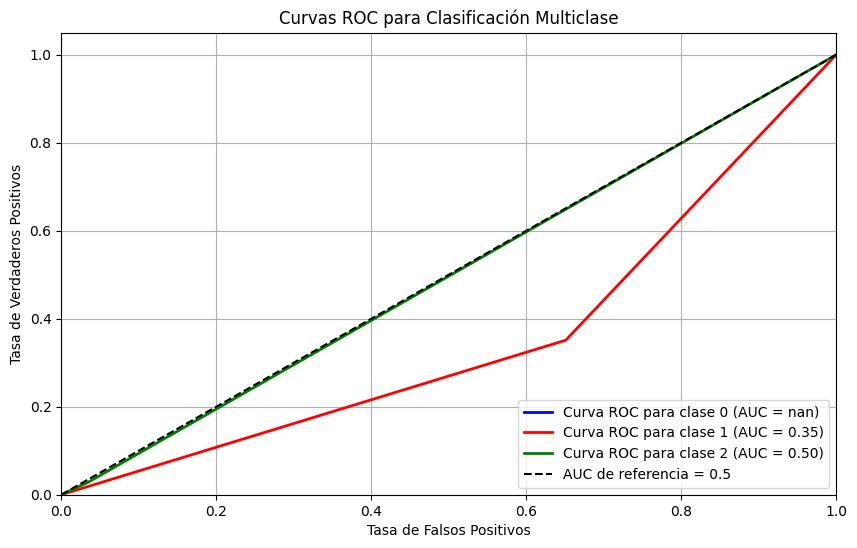

In [ ]:
# Graficar las curvas ROC para cada clase
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green']  # Colores para cada clase en el gráfico

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Curva ROC para clase {i} (AUC = {roc_auc[i]:0.2f})')

# Agregar línea diagonal de referencia
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='AUC de referencia = 0.5')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC para Clasificación Multiclase')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Este enfoque para visualizar las curvas ROC en un problema de clasificación multiclase permite comprender cómo se desempeña el modelo para cada clase individualmente. Los principales beneficios de este análisis son:

  * **Evaluación de la Separación por Clase**: La curva ROC y el AUC para cada clase proporcionan una visión clara de la capacidad del modelo para distinguir instancias de cada clase frente a las demás.
    
  * **Comparación del Rendimiento**: Comparar el AUC de cada clase ayuda a identificar si el modelo es particularmente bueno o deficiente en la clasificación de alguna clase específica, lo cual puede ser útil para ajustar o mejorar el modelo.
    
  * **Referencia a un Modelo Aleatorio**: La línea diagonal sirve como referencia, permitiendo evaluar qué tan por encima de un modelo aleatorio se encuentra el modelo para cada clase.

Estos resultados sugieren que el modelo necesita ajustes significativos para mejorar su capacidad de clasificación multiclase, con particular atención en la representación de clases y la selección de características.
La curva ROC muestra en dónde se encuentra el clasificador con respecto a la tasa de verdaderos positivos y falsos positivos. Un clasificador fenomenal debe estar en el punto (0,1), y si está debajo de la linea con pendiente 1, es un clasificador malo; sin embargo, hay que recordar que nuestro problema es multiclase y no un problema binario.

#### Matriz de confusión

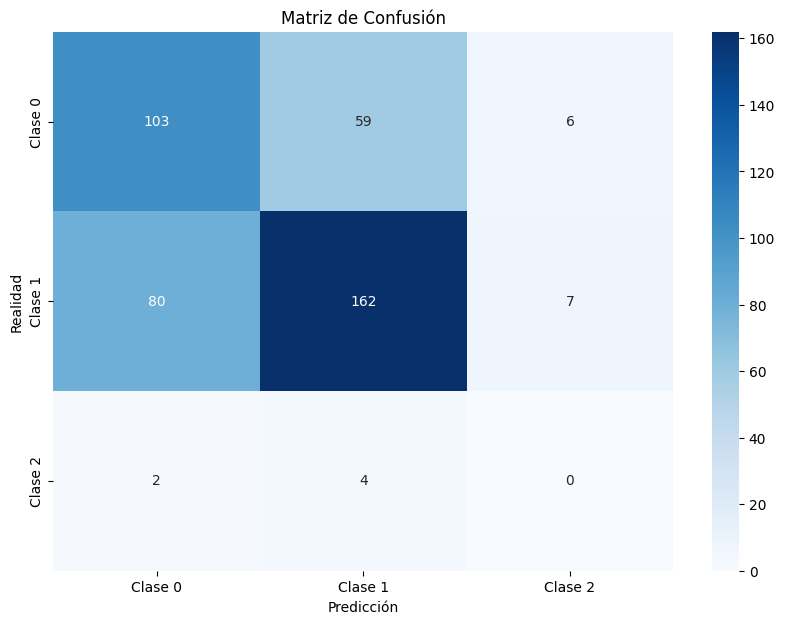

In [ ]:
# Generar predicciones en el conjunto de prueba usando el modelo final
y_pred = final_model.predict(meta_X_test)

# Calcular la matriz de confusión comparando las predicciones con los valores reales
cm = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión para visualizar el rendimiento del modelo
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clase 0', 'Clase 1', 'Clase 2'],
            yticklabels=['Clase 0', 'Clase 1', 'Clase 2'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

Confusión Entre Clases 0 y 1: Hay una notable confusión entre las clases 0 y 1, donde el modelo clasifica erróneamente varias instancias de la clase 0 como clase 1 y viceversa. Esto podría indicar que las características que diferencian estas dos clases no son suficientemente distintivas, o que el modelo necesita ajustes en sus parámetros para mejorar la precisión en esta separación.

Desempeño Deficiente en la Clase 2: La clase 2 muestra un rendimiento pobre, con la mayoría de sus instancias clasificadas incorrectamente. Este patrón sugiere que el modelo no está capturando adecuadamente las características de esta clase, lo que podría deberse a:

  * Un desequilibrio en el conjunto de datos, con pocas instancias de la clase 2 en comparación con las otras clases.
  
  * La falta de características únicas que permitan al modelo diferenciar la clase 2 de las clases 0 y 1.

Esta matriz de confusión revela que el modelo tiene un rendimiento aceptable en la clase 1, mientras que enfrenta dificultades significativas en la clase 2 y cierta confusión entre las clases 0 y 1.

#### Curva de Precisión-Recall

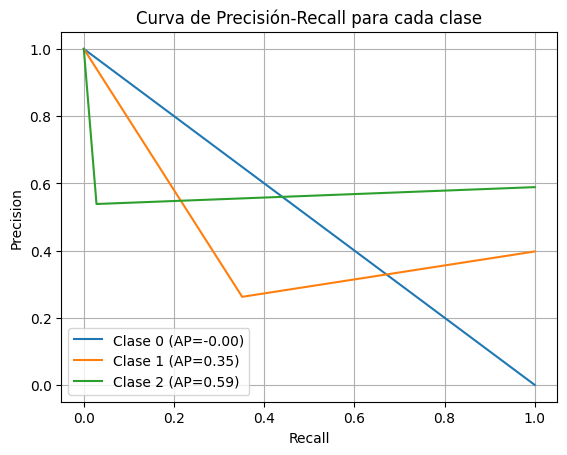

In [ ]:
# Generar las puntuaciones de predicción (probabilidades) del modelo en el conjunto de prueba
y_scores = final_model.predict_proba(meta_X_test)

# Graficar la curva de precisión-recall para cada clase
for i in range(y_scores.shape[1]):
    # Calcular la precisión y el recall para la clase i
    precision, recall, _ = precision_recall_curve((y_test == i).astype(int), y_scores[:, i])

    # Calcular el promedio de precisión (AP) para la clase i
    average_precision = average_precision_score((y_test == i).astype(int), y_scores[:, i])

    # Graficar la curva de precisión-recall para la clase i con el AP en la etiqueta
    plt.plot(recall, precision, label=f'Clase {i} (AP={average_precision:.2f})')

# Configuración del gráfico
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva de Precisión-Recall para cada clase')
plt.legend(loc='lower left')
plt.grid()
plt.show()

Este código permite evaluar el rendimiento del modelo en cada clase, utilizando la curva de precisión-recall y el promedio de precisión (AP) como métricas. Esto ayuda a identificar clases que necesitan mejorar, facilitando una optimización más dirigida y precisa en el proceso de ajuste del modelo.

**Rendimiento General del Modelo**: Las curvas de precisión-recall y los valores de AP muestran que el modelo tiene dificultades significativas para clasificar correctamente las clases 0 y 1, y un rendimiento ligeramente mejor en la clase 2. Sin embargo, todas las clases presentan AP relativamente bajos, lo que indica un desempeño subóptimo en general.

**Confusión entre Clases**: La clase 0 es particularmente problemática, con un AP de 0, lo que indica una fuerte confusión entre esta clase y las demás. Esto puede deberse a un desequilibrio en la representación de clases o a la falta de características distintivas que separen adecuadamente las clases.

Este análisis de las curvas de precisión-recall revela que el modelo tiene un rendimiento limitado en esta clasificación multiclase, con mejores resultados en la clase 2 pero un desempeño deficiente en las clases 0 y 1.



#### Diagrama de árbol

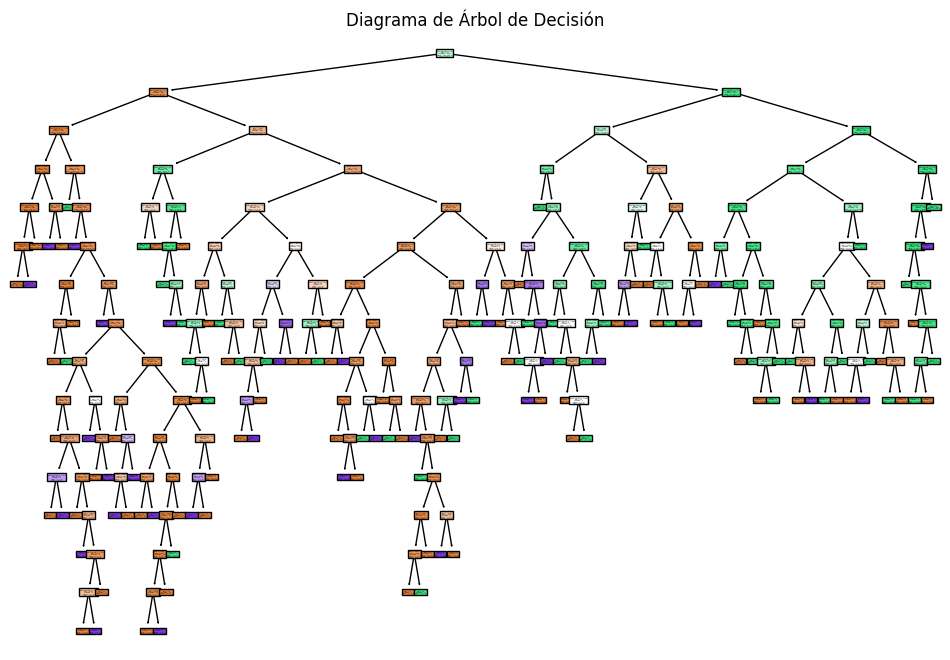

In [ ]:
# Configurar el tamaño de la figura para mejorar la visualización del árbol de decisión
plt.figure(figsize=(12, 8))

# Generar el diagrama del árbol de decisión
plot_tree(final_model,
          feature_names=["SVC", "MLP", "RandomForest"],  # Nombres de los modelos base como características
          class_names=["Clase 0", "Clase 1", "Clase 2"],  # Etiquetas de las clases para mejorar la legibilidad
          filled=True)  # Colorear las hojas y nodos en función de la clase para facilitar la interpretación

# Título de la gráfica
plt.title("Diagrama de Árbol de Decisión")
plt.show()

El diagrama de árbol de decisión proporciona una visión clara de cómo el modelo final combina las predicciones de los modelos base para realizar su clasificación. La visualización facilita la interpretación del modelo, lo que es valioso en aplicaciones donde se requiere explicar las decisiones o evaluar la relevancia de cada modelo base en el sistema de blending.

Este árbol de decisión proporciona una interpretación visual del sistema de blending utilizado, mostrando cómo el modelo combina las predicciones de los modelos base (SVC, MLP, RandomForest) para clasificar las instancias en diferentes clases. Aunque la profundidad y complejidad del árbol permiten capturar patrones complejos, también presentan algunos riesgos y oportunidades:

  1. Ventajas del Modelo:
      
      * Interpretación Detallada: La estructura del árbol permite ver cómo cada modelo base contribuye a la clasificación final. Esto puede ser útil para entender qué modelo base es más relevante en determinadas secciones del árbol.
        
      * Capacidad para Captar Relaciones Complejas: La profundidad del árbol y la cantidad de divisiones indican que el modelo final tiene una alta capacidad de ajuste, captando relaciones no lineales y aprovechando las fortalezas individuales de los modelos base.

  2. Riesgo de Sobreajuste:
      
      * La complejidad del árbol sugiere que el modelo podría estar ajustándose en exceso a los datos de entrenamiento, lo cual afectaría su capacidad de generalización en nuevos datos.
      
      * Si el rendimiento del modelo disminuye significativamente en conjuntos de prueba adicionales o en datos nuevos, podría ser útil limitar la profundidad del árbol (max_depth) o aumentar el mínimo de muestras requeridas para dividir un nodo (min_samples_split).

En resumen, este árbol de decisión muestra una estrategia de blending robusta y compleja que combina las predicciones de los modelos base de manera detallada. Si bien esta estructura captura patrones en el conjunto de entrenamiento, su complejidad sugiere la necesidad de una validación cuidadosa para asegurarse de que el modelo no esté sobreajustado y que tenga un rendimiento consistente en datos nuevos.

#### Gráfico de importancia de características

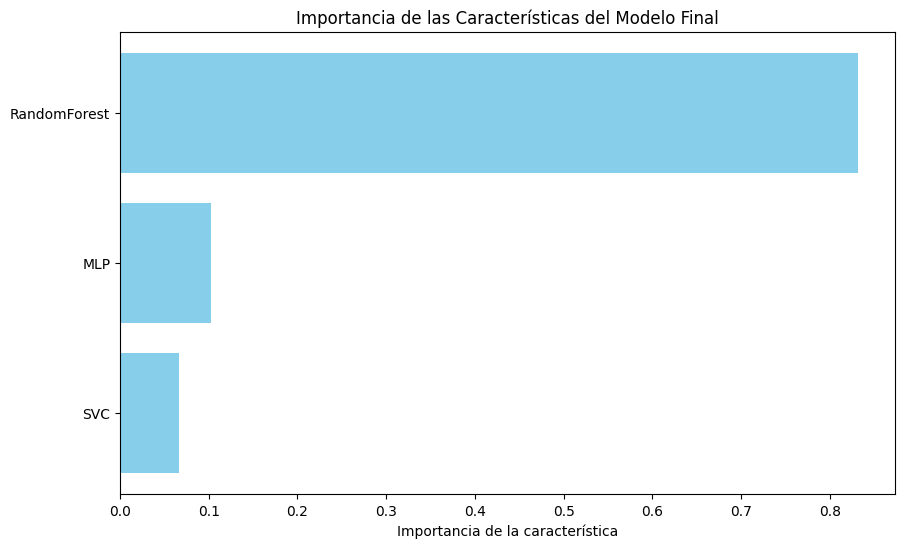

In [ ]:
# Nombres de los modelos base utilizados en el stacking/blending
feature_names = ["SVC", "MLP", "RandomForest"]

# Obtener la importancia de las características del modelo final (DecisionTreeClassifier)
importances = final_model.feature_importances_

# Ordenar las características por su importancia
indices = np.argsort(importances)

# Crear el gráfico de importancia de características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(importances)), np.array(feature_names)[indices])
plt.xlabel("Importancia de la característica")
plt.title("Importancia de las Características del Modelo Final")
plt.show()

El gráfico de importancia de características indica que el modelo RandomForest es el componente clave en el sistema de blending, aportando la mayor parte de la capacidad de predicción del modelo final. MLP añade una contribución moderada, posiblemente capturando algunos patrones específicos que RandomForest no identifica, mientras que SVC tiene una influencia muy limitada en las predicciones finales.

Este análisis ayuda a comprender mejor cómo los modelos base contribuyen al sistema de blending y proporciona una base para realizar ajustes que puedan mejorar el rendimiento general del modelo.

### Conclusión

Este proyecto consistió en la creación de un sistema de clasificación multiclase utilizando un enfoque de blending con varios modelos base y un modelo final de tipo árbol de decisión para combinar las predicciones. A continuación, se resumen los aspectos más relevantes y hallazgos de cada etapa:

  1. Preparación y Entrenamiento de los Modelos Base:
        
      * Se seleccionaron tres modelos base: SVC, MLPClassifier, y RandomForestClassifier, cada uno con características y capacidades diferentes para capturar patrones en los datos.
        
      * Cada modelo se entrenó con los datos originales y también con el conjunto balanceado mediante SMOTE (Synthetic Minority Over-sampling Technique), una técnica que genera ejemplos sintéticos para las clases minoritarias. Sin embargo, los resultados mostraron que el rendimiento era mejor cuando se dejaban los datos en su estado original, sin aplicar SMOTE. Este hallazgo indica que el modelo maneja adecuadamente el desbalance sin requerir sobremuestreo.
        
      * Adicionalmente, se utilizó Weighted Loss en cada modelo, lo que permite que el modelo ajuste automáticamente la importancia de cada clase en función de su representación en los datos. Esto ayudó a mejorar el rendimiento en clases minoritarias sin alterar el conjunto de datos.

  2. Construcción y Entrenamiento del Modelo Final (Blending):
        
      * Se utilizó un DecisionTreeClassifier como modelo final para combinar las salidas de los modelos base. Este árbol de decisión recibió las probabilidades de clase de cada modelo base y aprendió a tomar decisiones en función de esas probabilidades, formando un sistema de blending.
        
      * El árbol de decisión, al ser interpretable, proporcionó un marco claro para visualizar cómo las predicciones de cada modelo base contribuyen a la clasificación final. La visualización del árbol mostró una estructura compleja, lo que indica que el modelo final capturó patrones específicos en las predicciones de los modelos base.

    3. Evaluación del Modelo:
        
      * Se utilizaron varias métricas de rendimiento, incluidas la matriz de confusión, curvas ROC y curvas de precisión-recall para evaluar el desempeño del modelo en cada clase.
        
      * La matriz de confusión mostró que el modelo clasificaba correctamente una parte significativa de las instancias, aunque existía confusión entre ciertas clases (especialmente entre la clase 0 y la clase 1). Esta información fue útil para entender la precisión y los errores de clasificación del modelo.
        
      * Las curvas ROC y de precisión-recall por clase revelaron que, aunque el modelo tenía un rendimiento aceptable en la clase 2, tenía dificultades para clasificar correctamente las clases 0 y 1. Este resultado destacó la necesidad de mejorar la representación de estas clases o ajustar el modelo para mejorar su capacidad de generalización.

    4. Limitaciones y Áreas de Mejora:
        
      * Sobreajuste Potencial: La profundidad y complejidad del árbol de decisión podrían indicar un ajuste excesivo a los datos de entrenamiento. Este fenómeno es particularmente relevante si el modelo no logra generalizar bien en nuevos datos. Se podrían aplicar técnicas de poda del árbol o limitar su profundidad para reducir este riesgo.
        
      * Confusión entre Clases: La matriz de confusión y las curvas de precisión-recall sugirieron que el modelo tiende a confundir las clases 0 y 1. Esto podría deberse a un desbalance de clases o a una falta de características distintivas entre estas clases. Técnicas como el balanceo de clases (sobremuestreo o submuestreo) y la selección de características adicionales podrían mejorar la diferenciación entre estas clases.
        
      * Ajuste de Hiperparámetros: Realizar ajustes finos en los hiperparámetros del modelo final y los modelos base, o probar otros modelos meta como RandomForest para el blending, podría mejorar el rendimiento general.

En general, este proyecto implementó un sistema de blending robusto que combina múltiples modelos base para clasificar instancias en varias clases.